# MiniGPT: Training a GPT-Style Language Model From Scratch

### Celebal Technologies Internship — Final Project

**Project Type:** Natural Language Processing / Deep Learning  
**Architecture:** Decoder-Only Transformer  
**Language Modeling:** Character-Level  
**Framework:** PyTorch  
**Environment:** Python 3.12.10

---

## Project Overview

This project implements a small GPT-style language model completely
from scratch using PyTorch.

The objective is to understand the fundamental components behind
modern Generative Pre-trained Transformer (GPT) models by implementing
the major components manually rather than using a pre-built
Transformer or language-model library.

The project includes character-level tokenization, embeddings,
causal self-attention, multi-head attention, feed-forward networks,
residual connections, layer normalization, autoregressive text
generation, and model training using backpropagation and AdamW.

A simple Bigram language model is also implemented as a baseline to
compare its text generation capability with the Transformer-based
MiniGPT model.

## Project Objectives

The main objectives of this project are:

1. Understand how a GPT-style language model processes sequential text.
2. Implement character-level tokenization from scratch.
3. Build training and validation datasets.
4. Implement batch generation for language modeling.
5. Understand Query, Key, and Value representations.
6. Implement causal self-attention.
7. Implement multi-head attention.
8. Build Transformer blocks using attention and feed-forward layers.
9. Train a small decoder-only language model from scratch.
10. Evaluate the model using cross-entropy loss.
11. Generate text autoregressively using the trained model.
12. Compare the Transformer model with a simple Bigram baseline.

## Technologies and Concepts Used

### Programming Language
- Python

### Deep Learning Framework
- PyTorch

### Main Concepts
- Natural Language Processing
- Character-Level Tokenization
- Language Modeling
- Embeddings
- Self-Attention
- Multi-Head Attention
- Causal Masking
- Transformer Architecture
- Feed-Forward Neural Networks
- Residual Connections
- Layer Normalization
- Backpropagation
- Cross-Entropy Loss
- AdamW Optimization
- Autoregressive Text Generation

### Development Environment
- Jupyter Notebook
- Visual Studio Code

## Model Architecture

The MiniGPT model follows a decoder-only Transformer architecture.

```text
Input Text
    ↓
Character-Level Tokenization
    ↓
Token Embeddings
    +
Positional Embeddings
    ↓
Transformer Block
    ├── Layer Normalization
    ├── Multi-Head Causal Self-Attention
    ├── Residual Connection
    ├── Layer Normalization
    ├── Feed-Forward Network
    └── Residual Connection
    ↓
Repeated Transformer Blocks
    ↓
Final Layer Normalization
    ↓
Language Modeling Head
    ↓
Logits
    ↓
Next Character Prediction

## 1. Importing Required Libraries

We begin by importing the libraries required for data processing,
visualization, deep learning, and model training.

In [21]:
import sys
import math
import urllib.request
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
PyTorch version: 2.13.0+cpu


## 2. Device Configuration

Training a Transformer requires a significant number of matrix
operations. PyTorch can perform these operations using either the CPU
or a CUDA-enabled NVIDIA GPU.

The following code automatically selects the available device.

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Selected device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Training will use the CPU.")

Selected device: cpu
Training will use the CPU.


## 3. Loading the Dataset

For this project, we use the Tiny Shakespeare dataset.

The dataset consists of Shakespeare's plays and contains approximately
one million characters.

Instead of using a pre-trained language model, our MiniGPT will learn
language patterns directly from this raw text.

In [23]:
dataset_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

urllib.request.urlretrieve(dataset_url, "input.txt")

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


## 4. Loading and Inspecting the Text

We now read the dataset as a single string and perform basic exploratory
data analysis before converting the text into numerical representations.

In [24]:
with open("input.txt", "r", encoding="utf-8") as file:
    text = file.read()

print("Dataset loaded successfully.")
print("Total number of characters:", len(text))

Dataset loaded successfully.
Total number of characters: 1115394


### 4.1 Sample of the Dataset

Before training the model, we inspect a small portion of the raw text
to understand the structure of the dataset.

In [25]:
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



### 4.2 Basic Dataset Statistics

We calculate basic statistics such as the total number of characters,
number of unique characters, and the approximate vocabulary size.

In [26]:
print("Total characters:", len(text))
print("First character:", repr(text[0]))
print("Last character:", repr(text[-1]))

Total characters: 1115394
First character: 'F'
Last character: '\n'


In [27]:
chars = sorted(list(set(text)))

print("Unique characters:", len(chars))
print("Characters:")
print(chars)

Unique characters: 65
Characters:
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


### 4.3 Character Frequency Analysis

Character frequency analysis helps us understand the distribution of
characters in the dataset.

This also gives us an understanding of the vocabulary that the model
will need to learn.

In [28]:
char_counts = Counter(text)

most_common_chars = char_counts.most_common(15)

print("15 most frequent characters:\n")

for character, frequency in most_common_chars:
    print(repr(character), ":", frequency)

15 most frequent characters:

' ' : 169892
'e' : 94611
't' : 67009
'o' : 65798
'a' : 55507
'h' : 51310
's' : 49696
'r' : 48889
'n' : 48529
'i' : 45537
'\n' : 40000
'l' : 33339
'd' : 31358
'u' : 26584
'm' : 22243


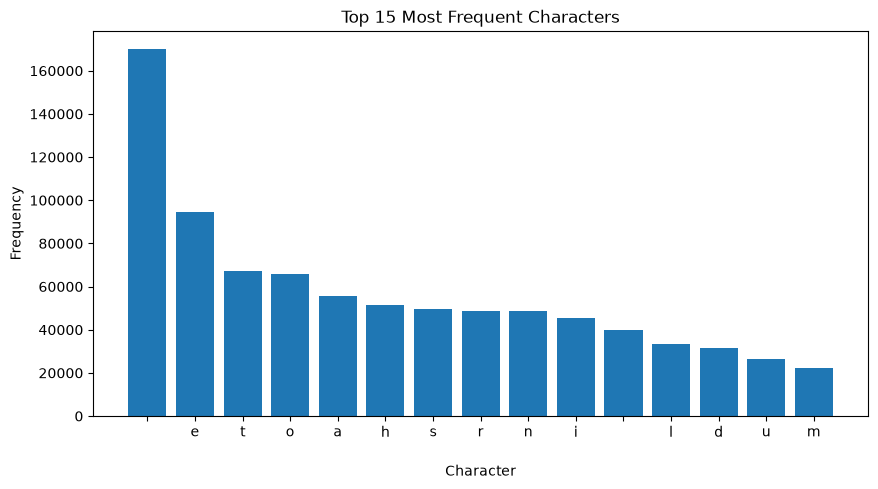

In [29]:
characters = [item[0] for item in most_common_chars]
frequencies = [item[1] for item in most_common_chars]

plt.figure(figsize=(10, 5))

plt.bar(characters, frequencies)

plt.title("Top 15 Most Frequent Characters")
plt.xlabel("Character")
plt.ylabel("Frequency")

plt.show()

## 5. Character-Level Tokenization

Large language models operate on numerical tokens rather than raw text.

For simplicity, this project uses character-level tokenization.

Each unique character in the dataset is assigned a unique integer ID.

For example:

    a → 0
    b → 1
    c → 2

The exact mapping depends on the vocabulary extracted from the dataset.

STRING TO INTEGER

In [30]:
stoi = {character: index for index, character in enumerate(chars)}

print("Character-to-index mapping:")
print(stoi)

Character-to-index mapping:
{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}


INTEGER TO STRING

In [31]:
itos = {index: character for index, character in enumerate(chars)}

print("Index-to-character mapping:")
print(itos)

Index-to-character mapping:
{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i', 48: 'j', 49: 'k', 50: 'l', 51: 'm', 52: 'n', 53: 'o', 54: 'p', 55: 'q', 56: 'r', 57: 's', 58: 't', 59: 'u', 60: 'v', 61: 'w', 62: 'x', 63: 'y', 64: 'z'}


### 5.1 Encoding Text

The encoder converts every character into its corresponding integer ID.

This numerical representation can then be processed by PyTorch.

In [32]:
def encode(text):
    return [stoi[character] for character in text]

In [33]:
sample_text = "Hello"

encoded_sample = encode(sample_text)

print("Original text:", sample_text)
print("Encoded text:", encoded_sample)

Original text: Hello
Encoded text: [20, 43, 50, 50, 53]


### 5.2 Decoding Numerical Tokens

The decoder performs the reverse operation.

It converts numerical token IDs back into readable characters.

In [34]:
def decode(numbers):
    return "".join(itos[index] for index in numbers)

In [35]:
decoded_sample = decode(encoded_sample)

print("Encoded:", encoded_sample)
print("Decoded:", decoded_sample)

Encoded: [20, 43, 50, 50, 53]
Decoded: Hello


### 5.3 Converting the Complete Dataset

We now encode the complete Shakespeare dataset and convert it into a
PyTorch tensor.

PyTorch tensors are the numerical structures used as inputs to the
neural network.

In [36]:
data = torch.tensor(encode(text), dtype=torch.long)

print("Tensor shape:", data.shape)
print("First 100 tokens:")
print(data[:100])

Tensor shape: torch.Size([1115394])
First 100 tokens:
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])


## 6. Train-Validation Split

To evaluate whether the model generalizes beyond the data it directly
learns from, we divide the dataset into:

- 90% training data
- 10% validation data

The training data is used to optimize the model parameters, while the
validation data is used to monitor performance on unseen text.

In [37]:
split_index = int(0.9 * len(data))

train_data = data[:split_index]
val_data = data[split_index:]

print("Training data:", len(train_data))
print("Validation data:", len(val_data))

Training data: 1003854
Validation data: 111540


## 7. Model Configuration

The model is intentionally kept small so that it can be trained on a
normal computer.

The main hyperparameters are defined below.

In [110]:
print("MiniGPT Configuration")
print("-" * 30)
print("Embedding dimension:", n_embd)
print("Attention heads:", n_head)
print("Transformer layers:", n_layer)
print("Context length:", block_size)
print("Batch size:", batch_size)
print("Learning rate:", learning_rate)
print("Training iterations:", max_iters)

MiniGPT Configuration
------------------------------
Embedding dimension: 128
Attention heads: 4
Transformer layers: 4
Context length: 128
Batch size: 64
Learning rate: 0.0003
Training iterations: 1000


In [38]:
batch_size = 64
block_size = 128

n_embd = 128
n_head = 4
n_layer = 4

dropout = 0.1
learning_rate = 3e-4

print("Batch size:", batch_size)
print("Context length:", block_size)
print("Embedding dimension:", n_embd)
print("Number of attention heads:", n_head)
print("Number of Transformer layers:", n_layer)
print("Dropout:", dropout)
print("Learning rate:", learning_rate)

Batch size: 64
Context length: 128
Embedding dimension: 128
Number of attention heads: 4
Number of Transformer layers: 4
Dropout: 0.1
Learning rate: 0.0003


## 8. Creating Training Batches

The language model is trained using next-token prediction.

For every input sequence, the target sequence is shifted one position
forward.

For example:

Input:
    H e l l

Target:
    e l l o

Therefore, the model learns to predict the next character at every
position in the sequence.

In [41]:
def get_batch(split):
    data_source = train_data if split == "train" else val_data

    start_positions = torch.randint(
        0,
        len(data_source) - block_size,
        (batch_size,)
    )

    x = torch.stack([
        data_source[i:i + block_size]
        for i in start_positions
    ])

    y = torch.stack([
        data_source[i + 1:i + block_size + 1]
        for i in start_positions
    ])

    x = x.to(device)
    y = y.to(device)

    return x, y

TEST BATCH GENERATION

In [42]:
x_batch, y_batch = get_batch("train")

print("Input batch shape:", x_batch.shape)
print("Target batch shape:", y_batch.shape)

Input batch shape: torch.Size([64, 128])
Target batch shape: torch.Size([64, 128])


### 8.1 Inspecting an Example Training Sequence

We decode one input and target sequence to verify that the target is
correctly shifted by one character.

In [43]:
print("INPUT:")
print(decode(x_batch[0].tolist()))

print("\nTARGET:")
print(decode(y_batch[0].tolist()))

INPUT:
ot thee!
My tears shall wipe away these bloody marks;
And no more words till they have flow'd their fill.

KING HENRY VI:
O pite

TARGET:
t thee!
My tears shall wipe away these bloody marks;
And no more words till they have flow'd their fill.

KING HENRY VI:
O piteo


# 9. Bigram Language Model — Baseline

Before implementing the Transformer architecture, we first create a
simple Bigram Language Model.

A Bigram Language Model predicts the next character using only the
current character.

For example:

    Current character → Next character

The model does not understand long-range context. This makes it a
useful baseline for comparison with our MiniGPT model.

Our Transformer should perform better because it can use information
from a much larger context through self-attention.

### 9.1 Bigram Model Idea

The Bigram model uses an embedding table where each input character
directly produces a vector of logits representing the probability of
the next character.

The model is intentionally simple and will serve as a baseline.

In [44]:
class BigramLanguageModel(nn.Module):
    
    def __init__(self, vocab_size):
        super().__init__()
        
        self.token_embedding_table = nn.Embedding(
            vocab_size,
            vocab_size
        )
    
    def forward(self, idx, targets=None):
        
        logits = self.token_embedding_table(idx)
        
        loss = None
        
        if targets is not None:
            B, T, C = logits.shape
            
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            
            loss = F.cross_entropy(logits, targets)
        
        return logits, loss

### 9.2 Understanding the Bigram Model

The model contains a single embedding table.

For each input character, the model produces a vector containing one
score for every possible character in the vocabulary.

These scores are called logits.

The cross-entropy loss measures how well the predicted next character
matches the actual target character.

In [45]:
vocab_size = len(chars)

bigram_model = BigramLanguageModel(vocab_size)

bigram_model = bigram_model.to(device)

print(bigram_model)

BigramLanguageModel(
  (token_embedding_table): Embedding(65, 65)
)


Test the Bigram Model

In [46]:
logits, loss = bigram_model(x_batch, y_batch)

print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())

Logits shape: torch.Size([8192, 65])
Initial loss: 4.536832809448242


### 9.3 Initial Loss

The Bigram model starts with randomly initialized parameters, so its
initial predictions are poor.

The loss should initially be close to the natural logarithm of the
vocabulary size.

For a vocabulary of approximately 65 characters:

    log(65) ≈ 4.17

Training should reduce this loss over time.

### 9.4 Training the Bigram Model

We use the AdamW optimizer to update the model parameters.

The optimizer uses gradients calculated through backpropagation to
reduce the cross-entropy loss.

In [47]:
bigram_optimizer = torch.optim.AdamW(
    bigram_model.parameters(),
    lr=learning_rate
)

print("Bigram optimizer created.")

Bigram optimizer created.


### 9.5 Training the Bigram Model

The model is trained for a small number of iterations.

Each iteration performs the following steps:

1. Generate a batch of training data.
2. Perform a forward pass.
3. Calculate the loss.
4. Calculate gradients using backpropagation.
5. Update the model parameters.
6. Reset the gradients.

In [48]:
bigram_iterations = 1000

bigram_losses = []

for step in tqdm(range(bigram_iterations)):
    
    xb, yb = get_batch("train")
    
    logits, loss = bigram_model(xb, yb)
    
    bigram_optimizer.zero_grad(set_to_none=True)
    
    loss.backward()
    
    bigram_optimizer.step()
    
    bigram_losses.append(loss.item())

print("Bigram training completed.")

  0%|          | 0/1000 [00:00<?, ?it/s]

Bigram training completed.


### 9.6 Bigram Training Loss

We visualize the training loss to determine whether the model is
learning from the training data.

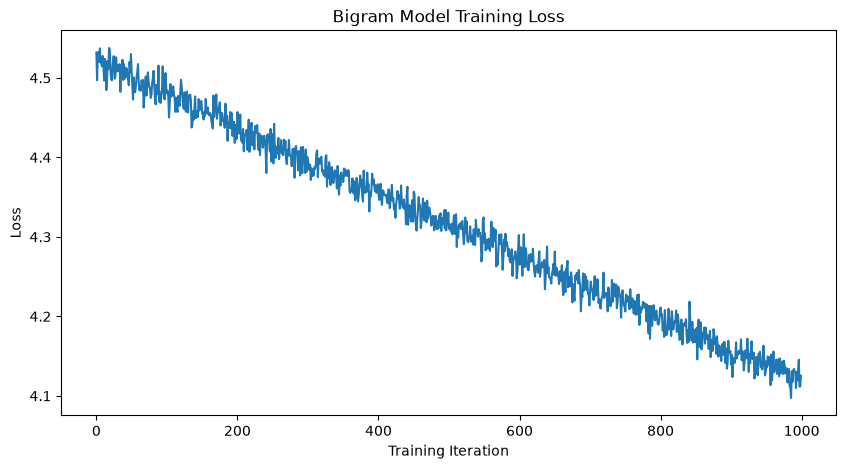

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(bigram_losses)

plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.title("Bigram Model Training Loss")

plt.show()

## 10. Text Generation — Bigram Baseline

A language model becomes useful when it can generate new text.

The generation process is:

1. Start with an initial character.
2. Predict the next character.
3. Sample one character from the predicted probability distribution.
4. Append the new character to the sequence.
5. Repeat the process.

In [50]:
@torch.no_grad()
def generate_bigram(model, idx, max_new_tokens):
    
    for _ in range(max_new_tokens):
        
        logits, _ = model(idx)
        
        logits = logits[:, -1, :]
        
        probabilities = F.softmax(logits, dim=-1)
        
        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )
        
        idx = torch.cat((idx, next_token), dim=1)
    
    return idx

Generate Text

In [51]:
start_character = torch.tensor(
    [[stoi["\n"]]],
    dtype=torch.long,
    device=device
)

generated = generate_bigram(
    bigram_model,
    start_character,
    max_new_tokens=500
)

print(decode(generated[0].tolist()))


Gjqw-kA3 wQ?M
qfQUXW.FP$3hkL SVAz? Mzpb 
.rbj:;TQ!;gVRdDXaRI:k
YFnHF?gHFRU3D-,NC'$bVDXWA&NDl,jKM!OwvJ
qOhCmuiFR:!J shth'ScJNHwT,PoExv?zyRm!O'rRbq'Z&s'.'g-vExA3snol3$CuPQtOzpPn!piF,MO?fSvk'n, tgVVxEkFijKp.ohthiplkZAqm!$IC'BxJ$;gvI
wCjWrq3bMe;:u'qlkStzNW'$,Wg,l,MUjOc&dg-osRqxSrX'hhiejY;!O:ttOvASaRU$sdeyaOvJwQyvORIS&gaoDRTNrDoyRTgQHTGPBHhCuaAFs'h'rIShoTgokcD?z?l;Lif
ZfoOwxT&dnXdnbDK;xy,Y&LwI
.aocHEhe
ugi$$IIS?fQfr$.d,-sQe3
Fs'ElXUL-viercHyX3y'ZlwRg,B!OjKJ?cgokegVEy.ao r!Vw?JfMLtNm.g,YUju a.mMOzN-z&


### 10.1 Limitations of the Bigram Model

The Bigram model has an extremely limited understanding of language.

It considers only the current character when predicting the next
character.

Therefore, it cannot effectively capture:

- Long-range dependencies
- Word-level patterns
- Sentence structure
- Relationships between distant characters
- Broader context

To overcome these limitations, we need a model that can attend to
multiple previous tokens.

This motivates the use of **self-attention**, which is the central
mechanism of the Transformer architecture.

# 11. Introduction to Self-Attention

Self-attention allows each token to determine which previous tokens
are important for predicting the next token.

For example, consider:

    "The dog chased the ball because it was..."

To predict what comes next, the model may need to understand what
"it" refers to.

A simple Bigram model cannot use this type of context.

Self-attention allows the model to consider relationships between
different positions in the sequence.

Our MiniGPT will use **causal self-attention**, meaning that a token
can only attend to itself and previous tokens.

Future tokens are hidden during training to prevent information
leakage.

## 12. Token Embeddings

A token embedding converts each token ID into a dense numerical vector.

Instead of representing a character using a single integer:

    'a' → 10

we represent it using a vector:

    'a' → [0.12, -0.45, 0.31, ...]

The embedding vectors are learned during training.

For this project, each token will be represented using a
128-dimensional embedding vector.

In [52]:
token_embedding = nn.Embedding(
    vocab_size,
    n_embd
)

print(token_embedding)

Embedding(65, 128)


Test Token Embedding

In [53]:
sample_tokens = x_batch[:, :5]

embedded_tokens = token_embedding(sample_tokens)

print("Input shape:", sample_tokens.shape)
print("Embedded shape:", embedded_tokens.shape)

Input shape: torch.Size([64, 5])
Embedded shape: torch.Size([64, 5, 128])


## 13. Positional Embeddings

Transformers do not inherently understand the order of tokens.

Therefore, we add a learnable positional embedding to the token
embedding.

For each position in the context window, the model learns a vector
representing that position.

The final representation is:

    Token Embedding + Positional Embedding

In [54]:
position_embedding = nn.Embedding(
    block_size,
    n_embd
)

print(position_embedding)

Embedding(128, 128)


Combine Token and Position Embeddings

In [55]:
positions = torch.arange(
    block_size,
    device=device
)

pos_emb = position_embedding(positions)

print("Position embedding shape:", pos_emb.shape)

Position embedding shape: torch.Size([128, 128])


Understand the Combined Representation

In [56]:
token_emb = token_embedding(x_batch)

position_emb = position_embedding(
    torch.arange(block_size, device=device)
)

combined_embeddings = token_emb + position_emb

print("Token embeddings:", token_emb.shape)
print("Position embeddings:", position_emb.shape)
print("Combined embeddings:", combined_embeddings.shape)

Token embeddings: torch.Size([64, 128, 128])
Position embeddings: torch.Size([128, 128])
Combined embeddings: torch.Size([64, 128, 128])


# 14. Self-Attention Mechanism

Self-attention is the key mechanism that allows a Transformer to
understand relationships between different tokens in a sequence.

Instead of looking only at the current token, self-attention allows
each token to determine which previous tokens are important.

For every token, three representations are calculated:

- Query (Q)
- Key (K)
- Value (V)

The attention mechanism uses these representations to calculate how
strongly each token should attend to other tokens.

## 14.1 Query, Key and Value

The three components have different roles:

### Query

Represents what the current token is looking for.

### Key

Represents what information each token contains that can be matched
against a query.

### Value

Contains the actual information that will be passed forward when a
token receives attention.

The attention calculation is based on the similarity between queries
and keys.

## 14.2 Scaled Dot-Product Attention

The basic attention equation is:

Attention(Q, K, V) = softmax(QKᵀ / √dₖ)V

where:

- Q = Query matrix
- K = Key matrix
- V = Value matrix
- dₖ = dimension of the key vectors

The scaling factor √dₖ prevents the dot products from becoming too
large, which helps maintain stable gradients.

In [61]:
# Small demonstration tensor for self-attention

B = 1
T = 4
C = n_embd

x_demo = torch.randn(
    B,
    T,
    C,
    device=device
)

print("Input shape:", x_demo.shape)

Input shape: torch.Size([1, 4, 128])


### 14.3 Creating Query, Key and Value

We create three linear transformations from the input embeddings.

Each input embedding is transformed into:

    Query
    Key
    Value

These transformations are learned during training.

In [62]:
head_size = 32

query_layer = nn.Linear(n_embd, head_size, bias=False)
key_layer = nn.Linear(n_embd, head_size, bias=False)
value_layer = nn.Linear(n_embd, head_size, bias=False)

print("Query layer:", query_layer)
print("Key layer:", key_layer)
print("Value layer:", value_layer)

Query layer: Linear(in_features=128, out_features=32, bias=False)
Key layer: Linear(in_features=128, out_features=32, bias=False)
Value layer: Linear(in_features=128, out_features=32, bias=False)


Now calculate Q, K and V.

In [63]:
Q = query_layer(x_demo)
K = key_layer(x_demo)
V = value_layer(x_demo)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([1, 4, 32])
K shape: torch.Size([1, 4, 32])
V shape: torch.Size([1, 4, 32])


## 14.4 Calculating Attention Scores

The similarity between queries and keys is calculated using a matrix
multiplication:

    Q × Kᵀ

The result tells us how strongly each token relates to every other
token.

For a sequence of length 4, the resulting attention matrix has the
shape:

    4 × 4

In [64]:
attention_scores = Q @ K.transpose(-2, -1)

print("Attention score shape:", attention_scores.shape)
print(attention_scores)

Attention score shape: torch.Size([1, 4, 4])
tensor([[[ 0.6452,  2.3732, -2.5450,  1.1752],
         [-3.2356,  0.8092, -2.4471,  1.5022],
         [ 0.2033,  1.7141,  3.3186,  0.9398],
         [-3.0655, -1.8108,  5.1971, -1.6646]]], grad_fn=<UnsafeViewBackward0>)


## 14.5 Scaling the Attention Scores

The attention scores are divided by the square root of the key
dimension.

This is known as scaled dot-product attention.

Scaling helps prevent extremely large values from entering the
softmax function.

In [65]:
attention_scores = attention_scores / math.sqrt(head_size)

print(attention_scores)

tensor([[[ 0.1141,  0.4195, -0.4499,  0.2078],
         [-0.5720,  0.1430, -0.4326,  0.2656],
         [ 0.0359,  0.3030,  0.5867,  0.1661],
         [-0.5419, -0.3201,  0.9187, -0.2943]]], grad_fn=<DivBackward0>)


# 15. Causal Self-Attention

GPT is an autoregressive language model.

This means that the model predicts the next token using only the
tokens that came before it.

Therefore, when processing a sequence, a token must not attend to
future tokens.

This is achieved using a causal mask.

For a sequence of length 4, the allowed attention pattern looks like:

    1 0 0 0
    1 1 0 0
    1 1 1 0
    1 1 1 1

A value of 1 means attention is allowed, while 0 means attention is
blocked.

In [67]:
causal_mask = torch.tril(
    torch.ones(T, T, device=device)
)

print(causal_mask)

tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])


### 15.1 Applying the Causal Mask

We cannot simply multiply the attention scores by the mask.

Instead, future positions are assigned negative infinity.

After applying softmax, these positions will receive probability
close to zero.

This prevents information from future tokens from reaching the
current token.

In [68]:
masked_attention_scores = attention_scores.masked_fill(
    causal_mask == 0,
    float("-inf")
)

print(masked_attention_scores)

tensor([[[ 0.1141,    -inf,    -inf,    -inf],
         [-0.5720,  0.1430,    -inf,    -inf],
         [ 0.0359,  0.3030,  0.5867,    -inf],
         [-0.5419, -0.3201,  0.9187, -0.2943]]], grad_fn=<MaskedFillBackward0>)


### 15.2 Applying Softmax

Softmax converts the attention scores into probabilities.

The probabilities determine how much attention each token gives to
the other available tokens.

Because of the causal mask, future tokens receive probability zero.

In [69]:
attention_weights = F.softmax(
    masked_attention_scores,
    dim=-1
)

print(attention_weights)

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3285, 0.6715, 0.0000, 0.0000],
         [0.2475, 0.3233, 0.4293, 0.0000],
         [0.1276, 0.1593, 0.5497, 0.1634]]], grad_fn=<SoftmaxBackward0>)


verify the rows sum to 1:

In [70]:
print("Row sums:")

print(attention_weights.sum(dim=-1))

Row sums:
tensor([[1., 1., 1., 1.]], grad_fn=<SumBackward1>)


## 16. Weighted Value Aggregation

The attention weights are multiplied by the Value matrix.

This creates a new representation for each token that contains
information gathered from the tokens it was allowed to attend to.

The calculation is:

    Attention Output = Attention Weights × V

In [71]:
attention_output = attention_weights @ V

print("Attention output shape:", attention_output.shape)

Attention output shape: torch.Size([1, 4, 32])


### 16.1 Complete Attention Flow

We have now implemented the complete mathematical process of one
causal self-attention head:

    Input Embeddings
          ↓
       Query
       Key
       Value
          ↓
      Q × Kᵀ
          ↓
       Scaling
          ↓
     Causal Mask
          ↓
        Softmax
          ↓
    Attention Weights
          ↓
     Weighted Values
          ↓
    Attention Output

# 17. Self-Attention Head

We now convert the attention calculations into a reusable neural
network module.

This module represents one attention head.

Later, multiple attention heads will be combined to create
Multi-Head Self-Attention.

In [72]:
class Head(nn.Module):
    
    def __init__(self, head_size):
        super().__init__()
        
        self.key = nn.Linear(
            n_embd,
            head_size,
            bias=False
        )
        
        self.query = nn.Linear(
            n_embd,
            head_size,
            bias=False
        )
        
        self.value = nn.Linear(
            n_embd,
            head_size,
            bias=False
        )
        
        self.register_buffer(
            "tril",
            torch.tril(
                torch.ones(block_size, block_size)
            )
        )
    
    def forward(self, x):
        
        B, T, C = x.shape
        
        k = self.key(x)
        q = self.query(x)
        
        attention_scores = q @ k.transpose(-2, -1)
        
        attention_scores = attention_scores * (
            k.shape[-1] ** -0.5
        )
        
        attention_scores = attention_scores.masked_fill(
            self.tril[:T, :T] == 0,
            float("-inf")
        )
        
        attention_weights = F.softmax(
            attention_scores,
            dim=-1
        )
        
        v = self.value(x)
        
        output = attention_weights @ v
        
        return output

In [73]:
test_head = Head(head_size)

head_output = test_head(combined_embeddings)

print("Input shape:", combined_embeddings.shape)
print("Head output shape:", head_output.shape)

Input shape: torch.Size([64, 128, 128])
Head output shape: torch.Size([64, 128, 32])


# 18. Multi-Head Self-Attention

A Transformer uses multiple self-attention heads operating in
parallel.

Each head can learn different relationships between tokens.

The outputs from all heads are concatenated and passed through a
linear projection.

In this project, we use:

    Number of heads = 4

    Embedding dimension = 128

    Head dimension = 32

Therefore:

    4 × 32 = 128

In [74]:
class MultiHeadAttention(nn.Module):
    
    def __init__(self, num_heads, head_size):
        super().__init__()
        
        self.heads = nn.ModuleList([
            Head(head_size)
            for _ in range(num_heads)
        ])
        
        self.projection = nn.Linear(
            num_heads * head_size,
            n_embd
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        
        head_outputs = [
            head(x)
            for head in self.heads
        ]
        
        combined = torch.cat(
            head_outputs,
            dim=-1
        )
        
        output = self.projection(combined)
        
        output = self.dropout(output)
        
        return output

Test Multi-Head Attention

In [75]:
multi_head = MultiHeadAttention(
    n_head,
    n_embd // n_head
)

multi_head_output = multi_head(combined_embeddings)

print("Input shape:", combined_embeddings.shape)
print("Multi-head output shape:", multi_head_output.shape)

Input shape: torch.Size([64, 128, 128])
Multi-head output shape: torch.Size([64, 128, 128])


# 19. Feed-Forward Network

After self-attention, each token representation is passed through a
position-wise feed-forward neural network.

The feed-forward network consists of:

    Linear Layer
        ↓
      ReLU
        ↓
    Linear Layer
        ↓
      Dropout

The first linear layer expands the representation.

The second linear layer projects it back to the original embedding
dimension.

This allows the model to learn additional nonlinear transformations
after the attention operation.

In [76]:
class FeedForward(nn.Module):
    
    def __init__(self, n_embd):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        return self.network(x)

Test Feed-Forward Network

In [77]:
feed_forward = FeedForward(n_embd)

ff_output = feed_forward(multi_head_output)

print("Input shape:", multi_head_output.shape)
print("Output shape:", ff_output.shape)

Input shape: torch.Size([64, 128, 128])
Output shape: torch.Size([64, 128, 128])


# 20. Residual Connections and Layer Normalization

Transformer blocks use residual connections around the attention and
feed-forward components.

A simplified structure is:

    Input
      ↓
    LayerNorm
      ↓
    Self-Attention
      ↓
    + Input
      ↓
    LayerNorm
      ↓
    Feed-Forward
      ↓
    + Previous Representation
      ↓
    Output

Residual connections help information and gradients flow through
deeper networks.

Layer normalization helps stabilize the activations during training.

# 21. Transformer Block

A Transformer block combines:

- Layer Normalization
- Multi-Head Self-Attention
- Residual Connections
- Feed-Forward Network

Multiple Transformer blocks will later be stacked to form our MiniGPT
model.

In [78]:
class Block(nn.Module):
    
    def __init__(self, n_embd, n_head):
        super().__init__()
        
        head_size = n_embd // n_head
        
        self.self_attention = MultiHeadAttention(
            n_head,
            head_size
        )
        
        self.feed_forward = FeedForward(n_embd)
        
        self.layer_norm_1 = nn.LayerNorm(n_embd)
        self.layer_norm_2 = nn.LayerNorm(n_embd)
    
    def forward(self, x):
        
        x = x + self.self_attention(
            self.layer_norm_1(x)
        )
        
        x = x + self.feed_forward(
            self.layer_norm_2(x)
        )
        
        return x

In [79]:
transformer_block = Block(
    n_embd,
    n_head
)

block_output = transformer_block(
    combined_embeddings
)

print("Input shape:", combined_embeddings.shape)
print("Block output shape:", block_output.shape)

Input shape: torch.Size([64, 128, 128])
Block output shape: torch.Size([64, 128, 128])


# 22. MiniGPT Architecture

The complete architecture we have constructed so far is:

    Input Token IDs
          │
          ▼
    Token Embedding
          │
          +
    Positional Embedding
          │
          ▼
    Transformer Block 1
          │
          ▼
    Transformer Block 2
          │
          ▼
    Transformer Block 3
          │
          ▼
    Transformer Block 4
          │
          ▼
    Final Layer Normalization
          │
          ▼
    Linear Language Modeling Head
          │
          ▼
    Logits for Next-Token Prediction

# 23. Building the Complete MiniGPT Model

We have implemented all the individual components required for a
decoder-only Transformer.

We now combine these components into a complete MiniGPT model.

The model contains:

- Token embeddings
- Positional embeddings
- Multiple Transformer blocks
- Final layer normalization
- Language modeling head

The model will be trained from scratch on our character-level text
dataset.

In [80]:
class MiniGPT(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        # Token embeddings
        self.token_embedding_table = nn.Embedding(
            vocab_size,
            n_embd
        )
        
        # Positional embeddings
        self.position_embedding_table = nn.Embedding(
            block_size,
            n_embd
        )
        
        # Transformer blocks
        self.blocks = nn.Sequential(
            *[
                Block(n_embd, n_head)
                for _ in range(n_layer)
            ]
        )
        
        # Final layer normalization
        self.final_layer_norm = nn.LayerNorm(n_embd)
        
        # Language modeling head
        self.lm_head = nn.Linear(
            n_embd,
            vocab_size
        )
    
    def forward(self, idx, targets=None):
        
        B, T = idx.shape
        
        # Token embeddings
        token_embeddings = self.token_embedding_table(idx)
        
        # Position embeddings
        positions = torch.arange(
            T,
            device=device
        )
        
        position_embeddings = self.position_embedding_table(
            positions
        )
        
        # Combine token and position information
        x = token_embeddings + position_embeddings
        
        # Transformer blocks
        x = self.blocks(x)
        
        # Final normalization
        x = self.final_layer_norm(x)
        
        # Predict next token
        logits = self.lm_head(x)
        
        loss = None
        
        if targets is not None:
            
            B, T, C = logits.shape
            
            logits = logits.view(
                B * T,
                C
            )
            
            targets = targets.view(
                B * T
            )
            
            loss = F.cross_entropy(
                logits,
                targets
            )
        
        return logits, loss

## 23.1 Understanding the MiniGPT Forward Pass

For every input sequence, the model performs the following operations:

1. Convert token IDs into token embeddings.
2. Add positional embeddings.
3. Pass the representations through multiple Transformer blocks.
4. Apply final layer normalization.
5. Use a linear layer to produce logits for every vocabulary token.
6. Calculate cross-entropy loss when target tokens are provided.

The model therefore learns to predict the next character in the
sequence.

In [81]:
model = MiniGPT()

model = model.to(device)

print(model)

MiniGPT(
  (token_embedding_table): Embedding(65, 128)
  (position_embedding_table): Embedding(128, 128)
  (blocks): Sequential(
    (0): Block(
      (self_attention): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=128, out_features=32, bias=False)
            (query): Linear(in_features=128, out_features=32, bias=False)
            (value): Linear(in_features=128, out_features=32, bias=False)
          )
        )
        (projection): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (network): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=128, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (layer_norm_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (

## 23.2 Model Parameter Count

A major difference between our MiniGPT and a full GPT-2 model is the
number of parameters.

Our model intentionally uses a much smaller architecture so that it
can be trained on a normal computer.

We calculate the total number of trainable parameters below.

In [82]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total trainable parameters: {total_parameters:,}")

Total trainable parameters: 824,897


## 23.3 Testing the Complete Model

Before training, we perform a forward pass using one batch of training
data.

This confirms that all components of the Transformer are connected
correctly.

In [83]:
xb, yb = get_batch("train")

logits, loss = model(xb, yb)

print("Input shape:", xb.shape)
print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())

Input shape: torch.Size([64, 128])
Logits shape: torch.Size([8192, 65])
Initial loss: 4.300907611846924


VERIFY LOSS

In [84]:
print("Vocabulary size:", vocab_size)
print("Expected logits shape:", (batch_size, block_size, vocab_size))
print("Actual logits shape:", logits.shape)

Vocabulary size: 65
Expected logits shape: (64, 128, 65)
Actual logits shape: torch.Size([8192, 65])


## 23.4 Initial Model Loss

The model is currently untrained.

Therefore, its predictions are essentially random and the loss is
relatively high.

During training, the loss should decrease as the model learns patterns
from the text dataset.

The loss is calculated using cross-entropy between:

- The predicted next-token probabilities
- The actual next token in the training data

# 24. Training MiniGPT

The training process follows the standard deep learning workflow:

1. Sample a batch of training sequences.
2. Pass the sequences through MiniGPT.
3. Calculate cross-entropy loss.
4. Calculate gradients using backpropagation.
5. Update model parameters using AdamW.
6. Repeat for multiple iterations.

The model will gradually learn the statistical patterns present in
the training text.

OPTIMIZER

In [85]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)

print("AdamW optimizer initialized.")

AdamW optimizer initialized.


## 24.1 Evaluating Training and Validation Loss

To determine whether the model is learning effectively, we monitor
both training and validation loss.

Training loss measures performance on the data used to train the model.

Validation loss measures performance on unseen data.

A significant difference between the two can indicate overfitting.

In [89]:
@torch.no_grad()
def estimate_loss():
    
    model.eval()
    
    results = {}
    
    for split in ["train", "val"]:
        
        losses = torch.zeros(eval_iters)
        
        for k in range(eval_iters):
            
            X, Y = get_batch(split)
            
            _, loss = model(X, Y)
            
            losses[k] = loss.item()
        
        results[split] = losses.mean().item()
    
    model.train()
    
    return results

In [92]:
# Number of batches used for loss evaluation
eval_iters = 20

print("Evaluation iterations:", eval_iters)

Evaluation iterations: 20


CHECK EVALUATION

In [93]:
losses = estimate_loss()

print("Training loss:", losses["train"])
print("Validation loss:", losses["val"])

Training loss: 4.308953285217285
Validation loss: 4.314689636230469


# 25. Training MiniGPT From Scratch

The MiniGPT model is now ready for training.

During training, the model repeatedly:
1. Takes a batch of text sequences.
2. Predicts the next character.
3. Calculates cross-entropy loss.
4. Uses backpropagation to calculate gradients.
5. Updates its parameters using the AdamW optimizer.

The objective is to gradually reduce the training and validation loss.

In [94]:
# Training configuration

max_iters = 1000

training_losses = []
validation_losses = []

print("Training iterations:", max_iters)

Training iterations: 1000


In [96]:
# How often to evaluate training and validation loss

eval_interval = 100

print("Evaluation interval:", eval_interval)

Evaluation interval: 100


In [97]:
from tqdm import tqdm

for step in tqdm(range(max_iters)):

    # Evaluate the model periodically
    if step % eval_interval == 0 or step == max_iters - 1:

        losses = estimate_loss()

        training_losses.append(losses["train"])
        validation_losses.append(losses["val"])

        print(
            f"Step {step}: "
            f"Train Loss = {losses['train']:.4f}, "
            f"Validation Loss = {losses['val']:.4f}"
        )

    # Get a batch of training data
    xb, yb = get_batch("train")

    # Forward pass
    logits, loss = model(xb, yb)

    # Clear previous gradients
    optimizer.zero_grad(set_to_none=True)

    # Backpropagation
    loss.backward()

    # Update model parameters
    optimizer.step()

print("MiniGPT training completed.")

  0%|          | 0/1000 [00:00<?, ?it/s]

Step 0: Train Loss = 4.3086, Validation Loss = 4.3154


 10%|█         | 100/1000 [02:25<21:04,  1.40s/it]

Step 100: Train Loss = 2.6456, Validation Loss = 2.6437


 20%|██        | 200/1000 [04:40<15:33,  1.17s/it]  

...

Step 900: Train Loss = 2.0873, Validation Loss = 2.1316


100%|█████████▉| 999/1000 [22:07<00:01,  1.19s/it]

Step 999: Train Loss = 2.0549, Validation Loss = 2.0933


100%|██████████| 1000/1000 [22:20<00:00,  1.34s/it]

MiniGPT training completed.


# 26. Training and Validation Loss

The training and validation losses are used to evaluate how the
MiniGPT model learned during training.

A decreasing loss indicates that the model is improving its ability
to predict the next character in the sequence.

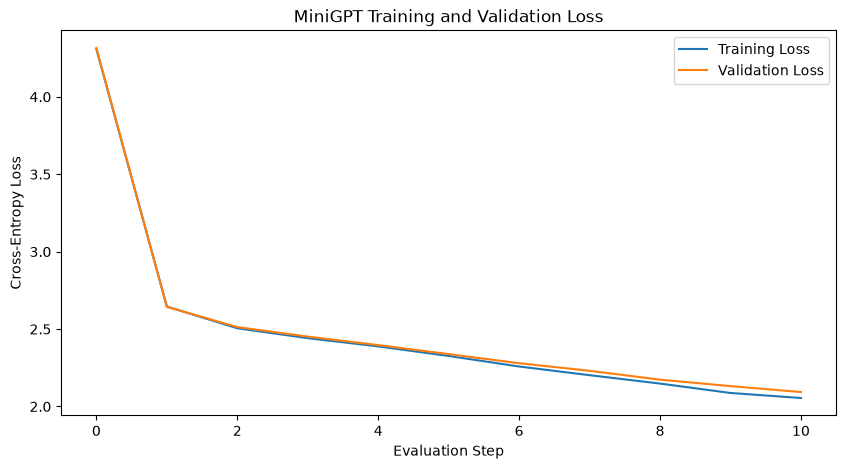

In [98]:
plt.figure(figsize=(10, 5))

plt.plot(
    training_losses,
    label="Training Loss"
)

plt.plot(
    validation_losses,
    label="Validation Loss"
)

plt.xlabel("Evaluation Step")
plt.ylabel("Cross-Entropy Loss")
plt.title("MiniGPT Training and Validation Loss")

plt.legend()

plt.show()

CHECK FINAL LOSS

In [99]:
print("Initial Training Loss:", training_losses[0])
print("Final Training Loss:", training_losses[-1])

print()

print("Initial Validation Loss:", validation_losses[0])
print("Final Validation Loss:", validation_losses[-1])

Initial Training Loss: 4.308597564697266
Final Training Loss: 2.0548789501190186

Initial Validation Loss: 4.31539249420166
Final Validation Loss: 2.093299388885498


# 27. Text Generation

After training, the MiniGPT model can generate new text
autoregressively.

The model starts with a given prompt and predicts one character at a
time.

The predicted character is then added to the context and used to
predict the next character.

This process continues until the requested number of new tokens has
been generated.

In [100]:
@torch.no_grad()
def generate_text(model, prompt, max_new_tokens=300):
    
    model.eval()
    
    # Convert the prompt into token IDs
    encoded_prompt = encode(prompt)
    
    idx = torch.tensor(
        [encoded_prompt],
        dtype=torch.long,
        device=device
    )
    
    # Generate one token at a time
    for _ in range(max_new_tokens):
        
        # Keep only the latest context window
        idx_cond = idx[:, -block_size:]
        
        # Get model predictions
        logits, _ = model(idx_cond)
        
        # Use predictions for the last position
        logits = logits[:, -1, :]
        
        # Convert logits to probabilities
        probabilities = F.softmax(
            logits,
            dim=-1
        )
        
        # Sample the next token
        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )
        
        # Add the predicted token to the sequence
        idx = torch.cat(
            (idx, next_token),
            dim=1
        )
    
    model.train()
    
    return decode(idx[0].tolist())

In [101]:
generated_text = generate_text(
    model,
    prompt="The ",
    max_new_tokens=300
)

print(generated_text)

The store rudst taulck, whe umpane whe
Samy if: thall aker a sive of aithe lees
Thas dot hee'dieaf the leaiknty, meate: my I grooke?
Fives les weall hive tom lim. Can tit!

ROUCHOLES:
When's, de tom off rorth.
My we thath smold So cow sell'
My momere, frewnt, sly lond he arist the isevip,

Amak:
Wheres 


Trying another prompt

In [102]:
generated_text = generate_text(
    model,
    prompt="I ",
    max_new_tokens=300
)

print(generated_text)

I fo fall hant,
How stay notigh, know and Rend butick;
So has pen thes you booure deld Jo with your I halll to
My wand heelt nower; I reave tho wiglant ment.
Vownoth, Wook, thive a me your it prown blvineerf
Yor tre thatse-stfYe mefom; know shoae him hom,
Be toth le king thall he mill halt I derd felB


One more generation

In [103]:
generated_text = generate_text(
    model,
    prompt="It ",
    max_new_tokens=300
)

print(generated_text)

It Enot dat;
Pith nope hir ald st-my Son
And mere, mos hinsed lo, ding of prot.

MARANT:
Aset fir dovesetin we.

PENESk wow far ances ithitioulsNont tho osled sue by
Them shee edis gin, nong, groy
ty lom hor a spriggenfeath owes go tr-d a nostaker,
Whave, not. Whaut rims thee me'sun of anchabuet!

Thin


# 28. Bigram Model vs MiniGPT

To understand the benefit of the Transformer architecture, we compare
the MiniGPT model with a simpler Bigram language model.

The Bigram model predicts the next character primarily from the
current character.

MiniGPT, on the other hand, uses causal self-attention to consider
information from the previous context.

This experiment demonstrates how increasing model context and
architectural complexity can improve language modeling.

In [104]:
print(type(bigram_model))

<class '__main__.BigramLanguageModel'>


Generating Bigram output

In [106]:
# Starting token for Bigram generation

start_character = "\n"

# Convert the starting character into a token ID tensor
start_token = torch.tensor(
    [encode(start_character)],
    dtype=torch.long,
    device=device
)

# Generate text using the Bigram model
bigram_output = generate_bigram(
    bigram_model,
    start_token,
    max_new_tokens=300
)

print("BIGRAM MODEL OUTPUT")
print("-" * 50)
print(decode(bigram_output[0].tolist()))

BIGRAM MODEL OUTPUT
--------------------------------------------------

vo.hCuMc:yUW-vc b'umGIgmuMOILgouM!$dASctt?&$gSQ!C
I-r-J$;SeQa:
IKaoci'ZDwC-,TCY:c?lE,XGmM&b3u JOG iDoU&aRb-lEwLOvVICPPT3uqYn?ddknwwfQw
BKEsita-,XT;;dHum-,RyfLU-pOgEohRnX,nJqI&;Kq'd,hvNWaUOLUTg&dfIaUPExShisTqvOYw&dR-Fsg,LEJ:e;caPo&DWdncMcshkn?u$G bpzorFZ&KFsHuqU$-GL
IEXCmpWIPBSe?C'QBeGo'nCouEwwbXk
Lj


MiniGPT comparison

In [107]:
minigpt_output = generate_text(
    model,
    prompt="\n",
    max_new_tokens=300
)

print("MINIGPT OUTPUT")
print("-" * 50)
print(minigpt_output)

MINIGPT OUTPUT
--------------------------------------------------

My sstxear
And you aftt, coo.
Why Gofen: umeld Tearty thy be bus of sitin but,
Thou loshe in me seswo muty knought sow,
Yow thy yout shan mewe th: gathty hant menoce,
Wo sunore thou fove not and dot fo darr.

WEELY:
Reast, sive flaw not dow ourighy, ond thagh soe?
Be WAfbla Nor fame as hem fould ung


## 29. Bigram Model vs MiniGPT — Results

The comparison shows a clear difference between the simple Bigram
language model and the Transformer-based MiniGPT model.

The Bigram model produces mostly random-looking character sequences
because it has very limited context when predicting the next
character.

MiniGPT produces more structured output and is able to reproduce
patterns such as words, punctuation, line breaks, and formatting
styles from the training dataset.

This improvement comes from the Transformer architecture, especially
causal self-attention, which allows the model to use information from
a larger context when predicting the next character.

The MiniGPT output is not expected to be grammatically perfect because
the model is intentionally small and was trained for a limited number
of iterations.

In [108]:
# Save the trained MiniGPT model

torch.save(
    model.state_dict(),
    "minigpt_model.pth"
)

print("MiniGPT model saved successfully as minigpt_model.pth")

MiniGPT model saved successfully as minigpt_model.pth


Saving the model configuration

In [109]:
import json

model_config = {
    "batch_size": batch_size,
    "block_size": block_size,
    "n_embd": n_embd,
    "n_head": n_head,
    "n_layer": n_layer,
    "dropout": dropout,
    "learning_rate": learning_rate,
    "max_iters": max_iters,
    "eval_iters": eval_iters,
    "eval_interval": eval_interval
}

with open("minigpt_config.json", "w") as f:
    json.dump(model_config, f, indent=4)

print("Model configuration saved successfully.")

Model configuration saved successfully.


# 31. Final Results

## Training Performance

The MiniGPT model showed a significant reduction in both training and
validation loss during training.

| Metric | Initial Loss | Final Loss |
|---|---:|---:|
| Training Loss | 4.309 | 2.055 |
| Validation Loss | 4.315 | 2.093 |

The training loss decreased by approximately 52%, while the
validation loss decreased by approximately 51%.

This indicates that the model successfully learned statistical
patterns from the training dataset.

## Text Generation

The trained MiniGPT model was able to generate new sequences of text
given an initial character or prompt.

The generated text was not expected to be grammatically perfect
because the model was intentionally kept small and trained for a
limited number of iterations.

However, the model learned patterns such as:

- Word-like character sequences
- Punctuation
- Line breaks
- Repeated textual structures
- Patterns resembling the original training corpus

## Bigram Baseline Comparison

The Bigram model generated mostly random-looking character sequences
because it has access to very limited context.

MiniGPT produced more structured sequences because its Transformer
architecture uses causal self-attention to process information from
the preceding context.

This demonstrates the advantage of contextual modeling over a simple
Bigram approach.

# 32. Limitations

Although the project successfully demonstrates the fundamental
components of a GPT-style language model, there are several
limitations.

1. The model is intentionally very small compared with production
   language models such as GPT-2.
2. The model uses character-level tokenization rather than more
   efficient subword tokenization.
3. Training was performed for a relatively small number of iterations.
4. The training dataset is limited in size.
5. The generated text can contain spelling and grammatical errors.
6. Training was performed on a CPU, which limits the practical model
   size and training duration.
7. The model has not been fine-tuned for a specific downstream task.

These limitations are intentional because the primary objective of
the project is educational understanding of the Transformer and GPT
architecture rather than building a production-scale language model.

# 33. Future Improvements

The project can be extended in several ways:

- Increase the size of the training dataset.
- Train for more iterations.
- Increase the number of Transformer layers.
- Increase embedding dimensions.
- Use subword tokenization such as Byte Pair Encoding.
- Train using a GPU for faster experimentation.
- Add temperature-based text generation.
- Experiment with different context lengths.
- Compare different attention configurations.
- Implement checkpoint-based training.
- Fine-tune the model on a domain-specific dataset.

# 35. Key Findings

The main findings from the project are:

1. A GPT-style language model can be implemented from scratch using
   relatively simple neural network components.

2. Causal self-attention allows the model to use contextual information
   when predicting the next character.

3. The model successfully learned patterns from the training corpus,
   demonstrated by the reduction in training and validation loss.

4. The trained MiniGPT generated text that reproduced several
   structural characteristics of the training data.

5. The Bigram baseline produced substantially less structured output,
   demonstrating the advantage of using contextual Transformer-based
   modeling.

6. A small Transformer can be trained from scratch on CPU when the
   model size and training configuration are kept manageable.

# 34. Conclusion

This project successfully implemented a miniature GPT-style
decoder-only Transformer from scratch using PyTorch.

The project provided hands-on understanding of the core components
behind modern language models, including tokenization, embeddings,
causal self-attention, multi-head attention, feed-forward networks,
residual connections, layer normalization, optimization, and
autoregressive text generation.

The model's training loss decreased from approximately 4.31 to 2.05,
while validation loss decreased from approximately 4.32 to 2.09.

A comparison with a simple Bigram language model also demonstrated
the importance of contextual information in language modeling.

Overall, this project provided practical experience in implementing,
training, evaluating, and using a Transformer-based language model
without relying on a pre-trained GPT model.

---

## Project Information

**Project:** MiniGPT — GPT-Style Language Model From Scratch  
**Internship:** Celebal Technologies  
**Domain:** Data Science / Natural Language Processing  
**Framework:** PyTorch  
**Model Type:** Decoder-Only Transformer  
**Training:** From Scratch  

### Author

**Parth**

This project was developed as part of the Celebal Technologies
internship final project.